# **Question No. 01**

In [1]:
!nvidia-smi -L || true
import torch, sys
print("Python:", sys.version.split()[0])
print("Torch :", torch.__version__)
print("CUDA? :", torch.cuda.is_available())
if torch.cuda.is_available(): print("GPU  :", torch.cuda.get_device_name(0))

GPU 0: Tesla T4 (UUID: GPU-69d77799-3cfd-a3d2-f5de-cd7740ac81c0)
Python: 3.12.12
Torch : 2.8.0+cu126
CUDA? : True
GPU  : Tesla T4


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# >>> EDIT THESE <<<
ZIP_PATH = "/content/drive/MyDrive/question01.zip"  # your uploaded zip on Drive
OUT_DIR  = "/content/signatures_q1/out"
RUN_NAME = "q1_from_zip_vae_wgan"

# No need to edit below
import os, pathlib
os.makedirs(f"{OUT_DIR}/{RUN_NAME}/checkpoints", exist_ok=True)
os.makedirs(f"{OUT_DIR}/{RUN_NAME}/results", exist_ok=True)
print("ZIP_PATH:", ZIP_PATH)
print("OUT_DIR :", OUT_DIR)

ZIP_PATH: /content/drive/MyDrive/question01.zip
OUT_DIR : /content/signatures_q1/out


In [4]:
import random, numpy as np, torch
SEED=1337
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.benchmark = True
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
import zipfile, shutil, os
from pathlib import Path

EXTRACT_ROOT = Path("/content/signatures_raw")
DATA_ROOT    = Path("/content/signatures_data")  # will contain train/ and test/

# fresh extract area
if EXTRACT_ROOT.exists(): shutil.rmtree(EXTRACT_ROOT)
EXTRACT_ROOT.mkdir(parents=True, exist_ok=True)

# extract the zip
assert Path(ZIP_PATH).exists(), f"ZIP not found at {ZIP_PATH}"
with zipfile.ZipFile(ZIP_PATH, 'r') as z:
    z.extractall(EXTRACT_ROOT)
print("Extracted to:", EXTRACT_ROOT)

# find images recursively
IMG_EXT = {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}
all_imgs = sorted([p for p in EXTRACT_ROOT.rglob("*") if p.suffix.lower() in IMG_EXT])
print("Found images:", len(all_imgs))
assert len(all_imgs) > 0, "No images detected in the ZIP (check contents)."

# If train/test exist already, point to them; else create 90/10 split
maybe_train = [p for p in EXTRACT_ROOT.glob("**/train") if p.is_dir()]
maybe_test  = [p for p in EXTRACT_ROOT.glob("**/test")  if p.is_dir()]

if maybe_train and maybe_test:
    DATA_ROOT = Path(os.path.commonpath([str(maybe_train[0].parent), str(maybe_test[0].parent)]))
    print("Detected pre-made splits at:", DATA_ROOT)
else:
    import random
    if DATA_ROOT.exists(): shutil.rmtree(DATA_ROOT)
    (DATA_ROOT/"train").mkdir(parents=True, exist_ok=True)
    (DATA_ROOT/"test").mkdir(parents=True, exist_ok=True)

    random.shuffle(all_imgs)
    split = int(0.9*len(all_imgs))
    for p in all_imgs[:split]:
        shutil.copy2(p, DATA_ROOT/"train"/p.name)
    for p in all_imgs[split:]:
        shutil.copy2(p, DATA_ROOT/"test"/p.name)
    print(f"Created splits: train={split} | test={len(all_imgs)-split}")

print("DATA_ROOT =", DATA_ROOT)


Extracted to: /content/signatures_raw
Found images: 4298
Detected pre-made splits at: /content/signatures_raw/sign_data
DATA_ROOT = /content/signatures_raw/sign_data


In [6]:
from pathlib import Path
from PIL import Image, ImageOps, ImageFilter
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torch, torchvision

IMG_SIZE = 64
BATCH    = 128     # reduce if VRAM is tight (e.g., 96 or 64)
WORKERS  = 2

def elastic_like():
    def f(img):
        return img.filter(ImageFilter.SMOOTH_MORE)
    return T.Lambda(f)

# preprocess: autocontrast; ensure light bg & dark ink if needed
def preprocess_pil(img):
    img = ImageOps.autocontrast(img)
    # Heuristic invert if background seems darker than foreground
    if img.convert("L").histogram()[0] < img.convert("L").histogram()[-1]:
        img = ImageOps.invert(img)
    return img

class SigFolder(Dataset):
    def __init__(self, root, split, aug=True):
        self.files = sorted([p for p in (Path(root)/split).rglob("*")
                             if p.suffix.lower() in {".png",".jpg",".jpeg",".bmp",".tif",".tiff"}])
        self.aug = aug
        base = [
            T.Resize((IMG_SIZE, IMG_SIZE), antialias=True),
            T.ToTensor(),
            T.Lambda(lambda x: x.mean(0, keepdim=True)),   # -> (1,H,W)
            T.Normalize([0.5],[0.5])                       # [-1,1]
        ]
        if aug:
            self.tf = T.Compose([
                T.Lambda(preprocess_pil),
                T.RandomApply([T.RandomAffine(6, translate=(0.05,0.05), scale=(0.96,1.04), shear=4)], p=0.7),
                T.RandomApply([elastic_like()], p=0.25),
                T.RandomApply([T.GaussianBlur(3, sigma=(0.1,1.0))], p=0.2),
                T.RandomAdjustSharpness(1.3, p=0.3),
                *base
            ])
        else:
            self.tf = T.Compose([T.Lambda(preprocess_pil), *base])
        if not self.files:
            print(f"[WARN] No images in {(Path(root)/split)}")

    def __len__(self): return len(self.files)

    def __getitem__(self, i):
        img = Image.open(self.files[i]).convert("RGB")
        return self.tf(img)

train_ds = SigFolder(DATA_ROOT, "train", aug=True)
test_ds  = SigFolder(DATA_ROOT, "test",  aug=False)

train_dl = DataLoader(train_ds, batch_size=BATCH, shuffle=True,  num_workers=WORKERS, pin_memory=True, drop_last=True)
test_dl  = DataLoader(test_ds,  batch_size=BATCH, shuffle=False, num_workers=WORKERS, pin_memory=True)
len(train_ds), len(test_ds)

(1649, 500)

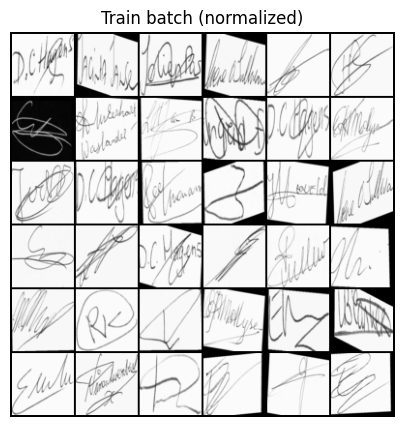

In [8]:
import torchvision.utils as vutils, matplotlib.pyplot as plt, torch
xb = next(iter(train_dl))
grid = vutils.make_grid(xb[:36], nrow=6, normalize=True, value_range=(-1,1))
plt.figure(figsize=(5,5)); plt.axis("off"); plt.title("Train batch (normalized)")
plt.imshow(grid.permute(1,2,0).cpu().numpy()); plt.show()

In [9]:
import torch.nn as nn, torch.nn.functional as F, torch

LATENT=64

class Encoder(nn.Module):
    def __init__(self, zdim=LATENT):
        super().__init__()
        self.c = nn.Sequential(
            nn.Conv2d(1,32,4,2,1),  nn.LeakyReLU(0.2,True),
            nn.Conv2d(32,64,4,2,1), nn.BatchNorm2d(64),  nn.LeakyReLU(0.2,True),
            nn.Conv2d(64,128,4,2,1),nn.BatchNorm2d(128), nn.LeakyReLU(0.2,True),
            nn.Conv2d(128,256,4,2,1),nn.BatchNorm2d(256),nn.LeakyReLU(0.2,True),
        )
        self.mu   = nn.Linear(256*4*4, zdim)
        self.logv = nn.Linear(256*4*4, zdim)
    def forward(self,x):
        h = self.c(x).flatten(1)
        return self.mu(h), self.logv(h)

class Decoder(nn.Module):
    def __init__(self, zdim=LATENT):
        super().__init__()
        self.fc = nn.Linear(zdim, 256*4*4)
        self.d = nn.Sequential(
            nn.ConvTranspose2d(256,128,4,2,1), nn.BatchNorm2d(128), nn.ReLU(True),
            nn.ConvTranspose2d(128,64,4,2,1),  nn.BatchNorm2d(64),  nn.ReLU(True),
            nn.ConvTranspose2d(64,32,4,2,1),   nn.BatchNorm2d(32),  nn.ReLU(True),
            nn.ConvTranspose2d(32,1,4,2,1),    nn.Tanh()
        )
    def forward(self,z):
        h = self.fc(z).view(-1,256,4,4)
        return self.d(h)

class VAE(nn.Module):
    def __init__(self, z=LATENT):
        super().__init__()
        self.enc, self.dec = Encoder(z), Decoder(z)
    def reparam(self, mu, logv):
        std = (0.5*logv).exp()
        return mu + torch.randn_like(std)*std
    def forward(self,x):
        mu, logv = self.enc(x)
        z = self.reparam(mu, logv)
        xh = self.dec(z)
        return xh, mu, logv

vae = VAE().to(device)
sum(p.numel() for p in vae.parameters())/1e6

2.169985

In [10]:
from torch.amp import GradScaler, autocast
import torch.nn.functional as F

# SSIM (installs if needed)
try:
    from pytorch_msssim import ssim
except Exception:
    !pip -q install pytorch-msssim
    from pytorch_msssim import ssim

def kl_div(mu, logvar):
    return -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())

# Sobel edge mag to keep pen strokes
def _sobel(img):
    img = img.float()
    kx = torch.tensor([[1,0,-1],[2,0,-2],[1,0,-1]], dtype=torch.float32, device=img.device).view(1,1,3,3)
    ky = torch.tensor([[1,2,1],[0,0,0],[-1,-2,-1]], dtype=torch.float32, device=img.device).view(1,1,3,3)
    gx = F.conv2d(img, kx, padding=1)
    gy = F.conv2d(img, ky, padding=1)
    return torch.sqrt(gx*gx + gy*gy + 1e-6)

EDGE_W = 0.05  # 0.05–0.1 usually good

def vae_loss(x, xhat, mu, logv, beta=1.0, use_ssim=True):
    # compute in fp32 OUTSIDE autocast (BCE is not AMP-safe)
    x, xhat = x.float(), xhat.float()
    x01, xh01 = (x+1)/2, (xhat+1)/2
    rec = F.binary_cross_entropy(xh01, x01, reduction='mean')
    edge = torch.mean(torch.abs(_sobel(x) - _sobel(xhat)))
    kld  = kl_div(mu, logv)
    if use_ssim:
        s = 1 - ssim(xh01, x01, data_range=1.0, size_average=True)
        return rec + EDGE_W*edge + 0.15*s + beta*kld, rec, kld, s
    return rec + EDGE_W*edge + beta*kld, rec, kld, torch.tensor(0.0, device=x.device)

In [11]:
import matplotlib.pyplot as plt, os

EPOCHS_VAE   = 40
LR_VAE       = 2e-4
BETA_FINAL   = 1.0
WARMUP_EPOCH = 10

opt_vae  = torch.optim.Adam(vae.parameters(), lr=LR_VAE, betas=(0.9,0.999))
scaler_v = GradScaler(device='cuda', enabled=(device.type=='cuda'))

hist_vae = {"loss":[], "rec":[], "kld":[], "ssim":[]}
def beta(ep): return min(1.0, ep/WARMUP_EPOCH)*BETA_FINAL

for ep in range(1, EPOCHS_VAE+1):
    vae.train(); agg=[0,0,0,0]; n=0
    for x in train_dl:
        x = x.to(device, non_blocking=True)
        opt_vae.zero_grad(set_to_none=True)

        with autocast(device_type='cuda', enabled=(device.type=='cuda')):
            xh, mu, logv = vae(x)

        # compute loss outside autocast
        L, rec, kld, s = vae_loss(x, xh, mu, logv, beta=beta(ep), use_ssim=True)

        scaler_v.scale(L).backward()
        scaler_v.step(opt_vae)
        scaler_v.update()

        bs = x.size(0)
        agg[0]+=L.item()*bs; agg[1]+=rec.item()*bs; agg[2]+=kld.item()*bs; agg[3]+=float(s)*bs; n+=bs

    hist_vae["loss"].append(agg[0]/n)
    hist_vae["rec"].append(agg[1]/n)
    hist_vae["kld"].append(agg[2]/n)
    hist_vae["ssim"].append(agg[3]/n)
    print(f"[VAE] {ep:03d}/{EPOCHS_VAE}  loss={hist_vae['loss'][-1]:.4f}  rec={hist_vae['rec'][-1]:.4f}  kld={hist_vae['kld'][-1]:.4f}")

plt.figure(); plt.plot(hist_vae["loss"], label="loss"); plt.plot(hist_vae["rec"], label="recon"); plt.plot(hist_vae["kld"], label="kld"); plt.legend(); plt.title("VAE losses")
plt.savefig(f"{OUT_DIR}/{RUN_NAME}/results/vae_losses.png", dpi=160, bbox_inches='tight'); plt.close()
torch.save(vae.state_dict(), f"{OUT_DIR}/{RUN_NAME}/checkpoints/vae.pt")

/tmp/ipython-input-682325730.py:31: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:835.)
  agg[0]+=L.item()*bs; agg[1]+=rec.item()*bs; agg[2]+=kld.item()*bs; agg[3]+=float(s)*bs; n+=bs


[VAE] 001/40  loss=1.3706  rec=1.0956  kld=0.1354
[VAE] 002/40  loss=1.5788  rec=1.0570  kld=1.3517
[VAE] 003/40  loss=1.0021  rec=0.6958  kld=0.3474
[VAE] 004/40  loss=0.9274  rec=0.6809  kld=0.1496
[VAE] 005/40  loss=0.8489  rec=0.6176  kld=0.0977
[VAE] 006/40  loss=0.7882  rec=0.5607  kld=0.0807
[VAE] 007/40  loss=0.7142  rec=0.4895  kld=0.0699
[VAE] 008/40  loss=0.6615  rec=0.4433  kld=0.0600
[VAE] 009/40  loss=0.6178  rec=0.3993  kld=0.0595
[VAE] 010/40  loss=0.5959  rec=0.3727  kld=0.0637
[VAE] 011/40  loss=0.5618  rec=0.3562  kld=0.0477
[VAE] 012/40  loss=0.5525  rec=0.3521  kld=0.0453
[VAE] 013/40  loss=0.5453  rec=0.3480  kld=0.0453
[VAE] 014/40  loss=0.5531  rec=0.3474  kld=0.0570
[VAE] 015/40  loss=0.5403  rec=0.3442  kld=0.0480
[VAE] 016/40  loss=0.5355  rec=0.3454  kld=0.0427
[VAE] 017/40  loss=0.5360  rec=0.3395  kld=0.0525
[VAE] 018/40  loss=0.5215  rec=0.3407  kld=0.0359
[VAE] 019/40  loss=0.5191  rec=0.3411  kld=0.0337
[VAE] 020/40  loss=0.5139  rec=0.3406  kld=0.0300


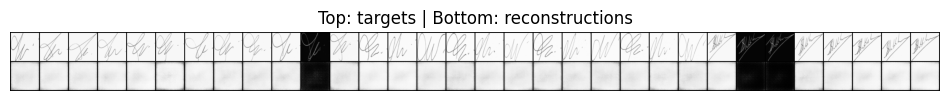

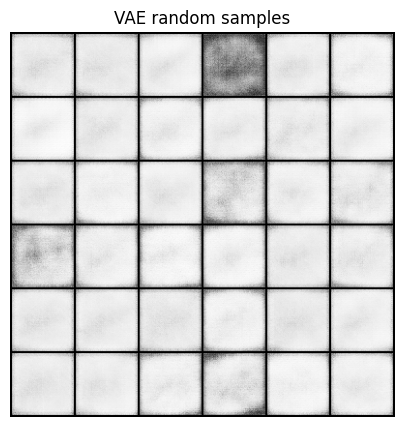

Test Reconstruction (BCE): 0.259494


In [12]:
import torchvision.utils as vutils, matplotlib.pyplot as plt, torch
vae.eval()
with torch.no_grad():
    xb = next(iter(test_dl)).to(device)[:32]
    xh, _, _ = vae(xb)
    grid = vutils.make_grid(torch.cat([xb, xh],0), nrow=32, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(12,3)); plt.axis("off"); plt.title("Top: targets | Bottom: reconstructions")
    plt.imshow(grid.permute(1,2,0).cpu().numpy()); plt.show()
    plt.imsave(f"{OUT_DIR}/{RUN_NAME}/results/vae_recon.png", grid.permute(1,2,0).cpu().numpy())

    z = torch.randn(36, LATENT, device=device)
    s = vae.dec(z)
    grid2 = vutils.make_grid(s, nrow=6, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(5,5)); plt.axis("off"); plt.title("VAE random samples")
    plt.imshow(grid2.permute(1,2,0).cpu().numpy()); plt.show()
    plt.imsave(f"{OUT_DIR}/{RUN_NAME}/results/vae_samples.png", grid2.permute(1,2,0).cpu().numpy())

# test reconstruction (BCE part)
tot=0; n=0
with torch.no_grad():
    for x in test_dl:
        x = x.to(device)
        xh, mu, logv = vae(x)
        L, rec, kld, s = vae_loss(x, xh, mu, logv, beta=BETA_FINAL, use_ssim=True)
        tot += rec.item()*x.size(0); n += x.size(0)
test_rec = tot/n
print("Test Reconstruction (BCE):", round(test_rec,6))

In [13]:
import torch.nn as nn
import torch.nn.utils.parametrizations as P
import torch

ZDIM=128

class G(nn.Module):
    def __init__(self, z=ZDIM, ch=64):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z, ch*8, 4,1,0, bias=False), nn.BatchNorm2d(ch*8), nn.ReLU(True),
            nn.ConvTranspose2d(ch*8, ch*4, 4,2,1, bias=False), nn.BatchNorm2d(ch*4), nn.ReLU(True),
            nn.ConvTranspose2d(ch*4, ch*2, 4,2,1, bias=False), nn.BatchNorm2d(ch*2), nn.ReLU(True),
            nn.ConvTranspose2d(ch*2, ch,   4,2,1, bias=False), nn.BatchNorm2d(ch),   nn.ReLU(True),
            nn.ConvTranspose2d(ch, 1,      4,2,1, bias=False), nn.Tanh()
        )
    def forward(self,z): return self.net(z.view(z.size(0), ZDIM,1,1))

def sconv(ic,oc,k,s,p): return P.spectral_norm(nn.Conv2d(ic,oc,k,s,p))

class D(nn.Module):
    def __init__(self, ch=64):
        super().__init__()
        self.c1 = nn.Sequential(sconv(1,ch,4,2,1), nn.LeakyReLU(0.2,True))
        self.c2 = nn.Sequential(sconv(ch,ch*2,4,2,1), nn.LeakyReLU(0.2,True))
        self.c3 = nn.Sequential(sconv(ch*2,ch*4,4,2,1), nn.LeakyReLU(0.2,True))
        self.c4 = nn.Sequential(sconv(ch*4,ch*8,4,2,1), nn.LeakyReLU(0.2,True))
        self.out= nn.Conv2d(ch*8,1,4,1,0)
    def forward(self,x, return_feats=False):
        f1 = self.c1(x); f2 = self.c2(f1); f3 = self.c3(f2); f4 = self.c4(f3)
        s  = self.out(f4).view(-1)
        if return_feats: return s, (f1.mean([2,3]), f2.mean([2,3]), f3.mean([2,3]), f4.mean([2,3]))
        return s

Gnet, Dnet = G().to(device), D().to(device)
sum(p.numel() for p in Gnet.parameters())/1e6, sum(p.numel() for p in Dnet.parameters())/1e6

(3.804032, 2.762689)

In [15]:
from torch.amp import GradScaler, autocast
import torchvision.utils as vutils, matplotlib.pyplot as plt, torch, os

LR_G, LR_D = 1e-4, 1.5e-4     # TTUR
optG = torch.optim.Adam(Gnet.parameters(), lr=LR_G, betas=(0.0,0.9))
optD = torch.optim.Adam(Dnet.parameters(), lr=LR_D, betas=(0.0,0.9))
scalerG = GradScaler(device='cuda', enabled=(device.type=='cuda'))

LAMBDA_GP = 10.0
N_CRITIC  = 5
EPOCHS_GAN= 80
FM_W      = 10.0              # feature-matching weight
NOISE0    = 0.06              # instance noise (start)
NOISE_END = 0.0

# EMA
ema_rate=0.999
G_ema = G().to(device); G_ema.load_state_dict(Gnet.state_dict())
@torch.no_grad()
def ema_update():
    for p,q in zip(G_ema.parameters(), Gnet.parameters()):
        p.data.mul_(ema_rate).add_(q.data, alpha=1-ema_rate)

def gradient_penalty(D, real, fake):
    b = real.size(0)
    eps = torch.rand(b,1,1,1, device=real.device)
    inter = (eps*real + (1-eps)*fake).requires_grad_(True)
    d_inter = D(inter)
    grads = torch.autograd.grad(d_inter, inter, torch.ones_like(d_inter), create_graph=True, retain_graph=True)[0]
    return ((grads.view(b,-1).norm(2,dim=1)-1)**2).mean()

lossesG, lossesD = [], []
fixed_z = torch.randn(64, ZDIM, device=device)

for ep in range(1, EPOCHS_GAN+1):
    inst_sigma = NOISE0 + (NOISE_END - NOISE0) * (ep / EPOCHS_GAN)

    for x in train_dl:
        x = x.to(device, non_blocking=True)

        # ----- Critic (NO autocast for GP stability)
        for _ in range(N_CRITIC):
            z = torch.randn(x.size(0), ZDIM, device=device)
            fake = Gnet(z).detach()
            if inst_sigma > 0:
                x    = x + inst_sigma*torch.randn_like(x)
                fake = fake + inst_sigma*torch.randn_like(fake)

            d_real = Dnet(x).mean()
            d_fake = Dnet(fake).mean()
            gp     = gradient_penalty(Dnet, x, fake)
            lossD  = (d_fake - d_real) + LAMBDA_GP*gp

            optD.zero_grad(set_to_none=True)
            lossD.backward()
            optD.step()

        # ----- Generator (AMP is fine)
        z = torch.randn(x.size(0), ZDIM, device=device)
        with autocast(device_type='cuda', enabled=(device.type=='cuda')):
            fake = Gnet(z)
            d_fake, f_fake = Dnet(fake, return_feats=True)
            d_real, f_real = Dnet(x,    return_feats=True)
            g_w = - d_fake.mean()
            fm  = sum(torch.mean(torch.abs(a - b)) for a,b in zip(f_fake, f_real))
            lossG = g_w + FM_W * fm

        optG.zero_grad(set_to_none=True)
        scalerG.scale(lossG).backward()
        scalerG.step(optG); scalerG.update()
        ema_update()

    lossesG.append(lossG.item()); lossesD.append(lossD.item())
    print(f"[WGAN-GP+FM] {ep:03d}/{EPOCHS_GAN}  D:{lossD.item():.3f}  G:{lossG.item():.3f}  (σ={inst_sigma:.3f})")

    # preview each epoch
    with torch.no_grad():
        samples = G_ema(fixed_z).clamp(-1,1)
    grid = vutils.make_grid(samples, nrow=8, normalize=True, value_range=(-1,1))
    plt.figure(figsize=(5,5)); plt.axis("off"); plt.title(f"Epoch {ep}")
    plt.imshow(grid.permute(1,2,0).cpu().numpy()); plt.show()
    plt.imsave(f"{OUT_DIR}/{RUN_NAME}/results/gan_samples_ep{ep:03d}.png", grid.permute(1,2,0).cpu().numpy())

# curves + checkpoints
plt.figure(); plt.plot(lossesD, label="D"); plt.plot(lossesG, label="G"); plt.legend(); plt.title("WGAN-GP+FM losses")
plt.savefig(f"{OUT_DIR}/{RUN_NAME}/results/gan_losses.png", dpi=300, bbox_inches='tight'); plt.close()

torch.save(G_ema.state_dict(), f"{OUT_DIR}/{RUN_NAME}/checkpoints/G_ema.pt")
torch.save(Dnet.state_dict(), f"{OUT_DIR}/{RUN_NAME}/checkpoints/D.pt")

Output hidden; open in https://colab.research.google.com to view.

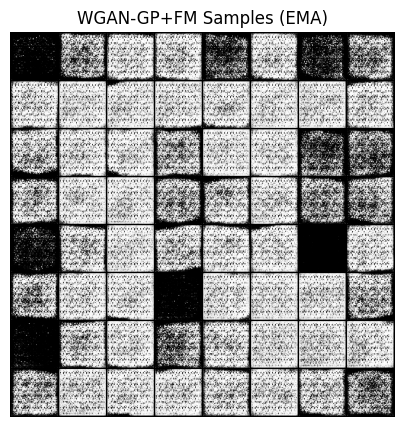

In [16]:
import torchvision.utils as vutils, matplotlib.pyplot as plt, torch
G_ema.eval()
with torch.no_grad():
    z = torch.randn(64, ZDIM, device=device)
    s = G_ema(z)
grid = vutils.make_grid(s, nrow=8, normalize=True, value_range=(-1,1))
plt.figure(figsize=(5,5)); plt.axis("off"); plt.title("WGAN-GP+FM Samples (EMA)")
plt.imshow(grid.permute(1,2,0).cpu().numpy()); plt.show()
plt.imsave(f"{OUT_DIR}/{RUN_NAME}/results/gan_samples_final.png", grid.permute(1,2,0).cpu().numpy())

In [17]:
# === Inline visualization helpers ===
from IPython.display import clear_output, display
from PIL import Image

def show_png(path, title=None, figsize=(5,5)):
    img = Image.open(path)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    if title: plt.title(title)
    plt.show()

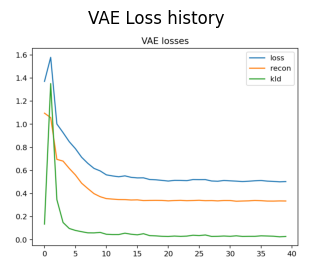

In [20]:
# 4) Show the saved PNGs inline (no need to re-generate)
show_png("/content/signatures_q1/out/q1_from_zip_vae_wgan/results/vae_losses.png", "VAE Loss history", figsize=(6,3))

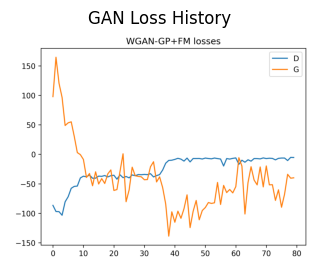

In [21]:
show_png("/content/signatures_q1/out/q1_from_zip_vae_wgan/results/gan_losses.png", "GAN Loss History", figsize=(6,3))

In [22]:
from datetime import datetime
log_path = f"{OUT_DIR}/{RUN_NAME}/results/summary.txt"
with open(log_path, "w") as f:
    f.write("Q1 — VAE + WGAN-GP+FM (Signatures from ZIP)\n")
    f.write(f"Run: {RUN_NAME}\nTime: {datetime.now()}\n")
    f.write(f"Train imgs: {len(train_ds)} | Test imgs: {len(test_ds)}\n")
    f.write(f"VAE: epochs={EPOCHS_VAE}, lr={LR_VAE}, beta_final={BETA_FINAL}, warmup={WARMUP_EPOCH}\n")
    f.write(f"WGAN-GP: epochs={EPOCHS_GAN}, n_critic={N_CRITIC}, λ_gp={LAMBDA_GP}, TTUR G/D={LR_G}/{LR_D}, FM_W={FM_W}\n")
    f.write(f"Test Reconstruction (BCE): {test_rec:.6f}\n")
    f.write("Artifacts: vae_recon.png, vae_samples.png, vae_losses.png, "
            "gan_losses.png, gan_samples_epXXX.png, gan_samples_final.png\n")
print("Saved:", log_path)

Saved: /content/signatures_q1/out/q1_from_zip_vae_wgan/results/summary.txt
